In [60]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2025-10-31 18:08:20--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.5’

input.txt.5         100%[===================>]   1.06M  --.-KB/s    in 0.006s  

2025-10-31 18:08:20 (170 MB/s) - ‘input.txt.5’ saved [1115394/1115394]



In [61]:
!pip install tokenizers
import os, random, unicodedata, json
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

SEED = 1337
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [62]:
CONFIG = {
    'vocab_size': 2000,
    'block_size': 128,
    'batch_size': 32,
    'n_embd': 384,
    'n_head': 6,
    'n_layer': 6,
    'dropout': 0.2,
    'learning_rate': 3e-4,
    'max_iters': 5000,
    'eval_interval': 500,
    'eval_iters': 200,
    'split_ratio': 0.9,
    'warmup_steps': 1000,
    'final_lr_scale': 0.05,
    'weight_decay': 0.1,
    'grad_clip': 1.0
}

In [63]:
def initialize_tokenizer():
    tokenizer_path = "shakespeare-bpe.json"

    if not os.path.exists(tokenizer_path):
        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = Whitespace()

        trainer = BpeTrainer(
            vocab_size=CONFIG['vocab_size'],
            special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
        )

        tokenizer.train(files=["input.txt"], trainer=trainer)
        tokenizer.save(tokenizer_path)
        return tokenizer
    else:
        tokenizer = Tokenizer.from_file(tokenizer_path)
        return tokenizer

def encode(text, tokenizer):
    return tokenizer.encode(text).ids

def decode(ids, tokenizer):
    return tokenizer.decode(ids)


In [64]:
def get_batch(split, data_splits, deterministic=False):
    data_split = data_splits['train'] if split == 'train' else data_splits['val']

    if deterministic:
        g = torch.Generator().manual_seed(42)
        ix = torch.randint(len(data_split) - CONFIG['block_size'], (CONFIG['batch_size'],), generator=g)
    else:
        ix = torch.randint(len(data_split) - CONFIG['block_size'], (CONFIG['batch_size'],))

    x = torch.stack([data_split[i:i+CONFIG['block_size']] for i in ix])
    y = torch.stack([data_split[i+1:i+CONFIG['block_size']+1] for i in ix])

    return (
        x.pin_memory().to(device, non_blocking=True),
        y.pin_memory().to(device, non_blocking=True)
    )

@torch.inference_mode()
def estimate_loss(model, data_splits):
    out = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(CONFIG['eval_iters'])
        for k in range(CONFIG['eval_iters']):
            X, Y = get_batch(split, data_splits, deterministic=True)
            _, loss = model(X, Y)
            losses[k] = loss.item()

        mean_loss = losses.mean()
        out[split] = {
            "loss": mean_loss.item(),
            "ppl": torch.exp(mean_loss).item()
        }

    model.train()
    return out


In [65]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(CONFIG['n_embd'], head_size, bias=False)
        self.query = nn.Linear(CONFIG['n_embd'], head_size, bias=False)
        self.value = nn.Linear(CONFIG['n_embd'], head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(CONFIG['block_size'], CONFIG['block_size'])))
        self.dropout = nn.Dropout(CONFIG['dropout'])

    def forward(self, x):
        B, T, _ = x.shape
        k = self.key(x)  # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)

        # Scaled dot-product attention
        dk = q.size(-1)
        wei = (q @ k.transpose(-2, -1)) * (dk ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        # Value transformation and aggregation
        v = self.value(x)  # (B, T, head_size)
        return wei @ v  # (B, T, head_size)

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(CONFIG['n_embd'], CONFIG['n_embd'])
        self.dropout = nn.Dropout(CONFIG['dropout'])

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(CONFIG['dropout']),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))  # Residual connection + layer norm
        x = x + self.ffwd(self.ln2(x))  # Residual connection + layer norm
        return x

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(CONFIG['vocab_size'], CONFIG['n_embd'])
        self.position_embedding_table = nn.Embedding(CONFIG['block_size'], CONFIG['n_embd'])
        self.blocks = nn.Sequential(*[Block(CONFIG['n_embd'], CONFIG['n_head']) for _ in range(CONFIG['n_layer'])])
        self.ln_f = nn.LayerNorm(CONFIG['n_embd'])
        self.lm_head = nn.Linear(CONFIG['n_embd'], CONFIG['vocab_size'])

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # Embed tokens and positions
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb

        # Forward through transformer blocks
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        # Calculate loss if targets provided
        if targets is None:
            return logits, None

        B, T, C = logits.shape
        logits = logits.view(B * T, C)
        targets = targets.view(B * T)
        loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            # Crop context to block_size
            idx_cond = idx[:, -CONFIG['block_size']:]

            # Get predictions
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]  # Focus on last time step

            # Apply temperature
            logits = logits / temperature

            # Apply top-k filtering if specified
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float('Inf')

            # Sample next token
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [66]:
def get_lr(step):
    if step < CONFIG['warmup_steps']:
        return CONFIG['learning_rate'] * (step + 1) / CONFIG['warmup_steps']

    progress = (step - CONFIG['warmup_steps']) / max(1, (CONFIG['max_iters'] - CONFIG['warmup_steps']))
    return CONFIG['learning_rate'] * (CONFIG['final_lr_scale'] + 0.5 * (1 - CONFIG['final_lr_scale']) * (1 + np.cos(np.pi * progress)))

def safe_ppl(loss):
    try:
        return float(np.exp(min(50.0, float(loss))))
    except Exception:
        return float('inf')

In [67]:
def main():
    # Set device
    global device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Initialize tokenizer
    tokenizer = initialize_tokenizer()

    # Test encode/decode
    test_text = "To be or not to be"
    encoded = encode(test_text, tokenizer)
    decoded = decode(encoded, tokenizer)
    print(f"Sample encoding: {encoded}")
    print(f"Decoded back: {decoded}")

    # Load and encode dataset
    with open("input.txt", "r", encoding="utf-8") as f:
        text = f.read()

    data = torch.tensor(encode(text, tokenizer), dtype=torch.long)

    # Train/validation split
    n = int(CONFIG['split_ratio'] * len(data))
    data_splits = {
        'train': data[:n],
        'val': data[n:]
    }

    print(f"Train tokens: {len(data_splits['train'])}, Val tokens: {len(data_splits['val'])}")

    # Initialize model
    model = GPTLanguageModel().to(device)
    model.lm_head.weight = model.token_embedding_table.weight  # Weight tying

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model has {total_params/1e6:.2f}M parameters")

    # Initialize optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )

    # Training tracking
    train_losses, val_losses, eval_steps = [], [], []

    # Training loop
    for iter in range(CONFIG['max_iters']):
        # Learning rate scheduling
        for param_group in optimizer.param_groups:
            param_group['lr'] = get_lr(iter)

        # Evaluation
        if iter % CONFIG['eval_interval'] == 0 or iter == CONFIG['max_iters'] - 1:
            losses = estimate_loss(model, data_splits)

            # Store for plotting
            train_losses.append(float(losses['train']['loss']))
            val_losses.append(float(losses['val']['loss']))
            eval_steps.append(int(iter))

            # Print progress
            t_loss, v_loss = losses['train']['loss'], losses['val']['loss']
            print(
                f"step {iter}: "
                f"train {t_loss:.4f} (ppl {safe_ppl(t_loss):.1f}), "
                f"val {v_loss:.4f} (ppl {safe_ppl(v_loss):.1f})"
            )

        # Training step
        xb, yb = get_batch('train', data_splits)
        _, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
        optimizer.step()

        # Print training loss periodically
        if iter % 500 == 0:
            print(f"step {iter}: loss {loss.item():.4f}")

    return model, train_losses, val_losses, eval_steps


In [68]:
if __name__ == "__main__":
    model, train_losses, val_losses, eval_steps = main()

Using device: cuda
✅ Loaded existing BPE tokenizer.
Sample encoding: [187, 95, 73, 113, 82, 95]
Decoded back: To be or not to be
Train tokens: 299198, Val tokens: 33245
Model has 11.46M parameters
step 0: train 248.9316 (ppl 5184705528587072045056.0), val 249.5437 (ppl 5184705528587072045056.0)
step 0: loss 243.4556
step 500: train 8.0146 (ppl 3024.9), val 7.8204 (ppl 2490.9)
step 500: loss 10.7139
step 1000: train 6.3573 (ppl 576.7), val 6.6445 (ppl 768.5)
step 1000: loss 8.2724
step 1500: train 5.6774 (ppl 292.2), val 6.0072 (ppl 406.3)
step 1500: loss 6.7769
step 2000: train 5.2393 (ppl 188.5), val 5.6514 (ppl 284.7)
step 2000: loss 5.7714
step 2500: train 5.0139 (ppl 150.5), val 5.4314 (ppl 228.5)
step 2500: loss 5.1638
step 3000: train 4.8440 (ppl 127.0), val 5.3078 (ppl 201.9)
step 3000: loss 5.1543
step 3500: train 4.7399 (ppl 114.4), val 5.2149 (ppl 184.0)
step 3500: loss 4.9161
step 4000: train 4.6492 (ppl 104.5), val 5.1467 (ppl 171.9)
step 4000: loss 4.6865
step 4500: train 

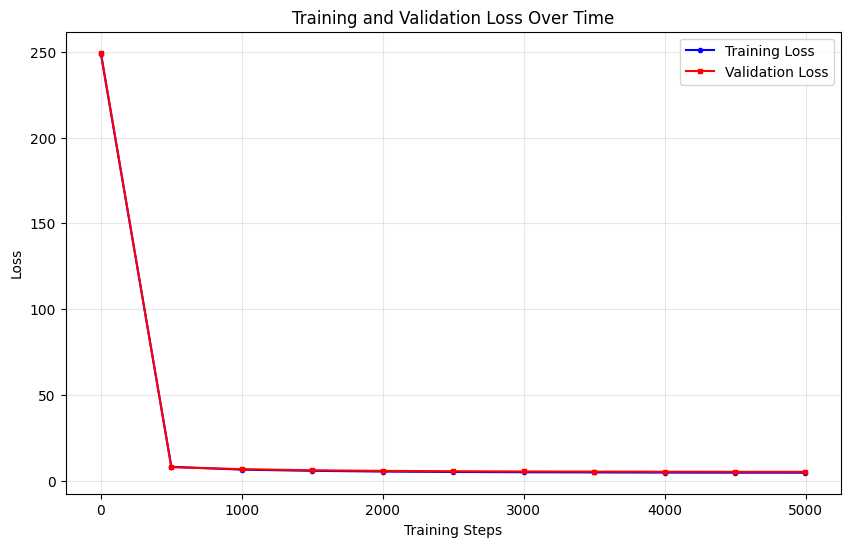

In [69]:
# Plot the losses
plt.figure(figsize=(10, 6))
plt.plot(eval_steps, train_losses, label='Training Loss', color='blue', marker='o', markersize=3)
plt.plot(eval_steps, val_losses, label='Validation Loss', color='red', marker='s', markersize=3)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
def generate_text(model, tokenizer, prompt="", max_new_tokens=500, temperature=0.8, top_k=40):
    if prompt:
        # Encode the prompt
        encoded = encode(prompt, tokenizer)
        context = torch.tensor([encoded], dtype=torch.long, device=device)
    else:
        # Start with a more meaningful context than zeros
        context = torch.tensor([[tokenizer.token_to_id("[BOS]")]], dtype=torch.long, device=device)

    with torch.no_grad():
        generated_ids = model.generate(
            context,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k
        )[0].tolist()

    return decode(generated_ids, tokenizer)

In [71]:
tokenizer = initialize_tokenizer()
prompts = [""]

for prompt in prompts:
    print(f"\n=== Prompt: '{prompt}' ===")
    for temp in [1]:
        text = generate_text(
            model,
            tokenizer,
            prompt=prompt,
            temperature=temp,
            top_k=40,
            max_new_tokens=200
        )
        print(f"Temp {temp}: {text}\n")

✅ Loaded existing BPE tokenizer.

=== Prompt: '' ===
Temp 1: lo y and I know , And say your grace , in this in th i ance on our grace , To be tr um pet ite ly ; the king and with the Duke breathe ' s to the house of me , ' d on . KING RICHARD II : Then , and look on s death , I will be thou ess ; yet you . RICHARD II : I be no con quest , thou but my name , and my life ; But in the queen of happy he that thy wife . KING RICHARD III : So tongue ' st ood , no d , That re pe ers ; which , so he could know his breast is he st to the world of the matter with my lord that I ' ll be content . W atch man n on - in the duke and we igh . R et st me , And the rest ; I be a le an ces en s , my lo ck and de ter . R ight ly when he not and dis d ain . BUCKINGHAM : That our tent ! QUEEN ELIZABETH

